# **Custom CNN**

In [1]:
import cv2
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kagglehub
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset, DataLoader
from torchvision import transforms, datasets
import torchvision.models as models
torch.manual_seed(42)

In [2]:
# install optuna for hyperparameter tuning
!pip install optuna -q
import optuna
from optuna.trial import TrialState


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 21.0 MB/s eta 0:00:00


In [3]:
#cheaking cuda
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

Using Device: cuda


In [4]:
#base path and resolve path
downloaded_path = kagglehub.dataset_download("orvile/brain-cancer-mri-dataset")
resolved_paths = glob.glob(os.path.join(downloaded_path, '**/Brain_Cancer'), recursive=True)
base_path = resolved_paths[0] if resolved_paths else downloaded_path


100%|██████████| 144M/144M [00:02<00:00, 62.9MB/s]

Extracting files...


In [5]:
#catagoris cheaking
categories = ['brain_glioma', 'brain_menin', 'brain_tumor']
num_classes = len(categories)

In [6]:
full_image_path_list = []
labels = []

for cls in categories:
    cls_path = os.path.join(base_path, cls)
    for img_name in os.listdir(cls_path):
        full_image_path_list.append(os.path.join(cls_path, img_name))
        labels.append(cls)

df = pd.DataFrame({
    'image': full_image_path_list,
    'label': labels
})

print(df)

                                                  image         label
0     /root/.cache/kagglehub/datasets/orvile/brain-c...  brain_glioma
1     /root/.cache/kagglehub/datasets/orvile/brain-c...  brain_glioma
2     /root/.cache/kagglehub/datasets/orvile/brain-c...  brain_glioma
3     /root/.cache/kagglehub/datasets/orvile/brain-c...  brain_glioma
4     /root/.cache/kagglehub/datasets/orvile/brain-c...  brain_glioma
...                                                 ...           ...
6051  /root/.cache/kagglehub/datasets/orvile/brain-c...   brain_tumor
6052  /root/.cache/kagglehub/datasets/orvile/brain-c...   brain_tumor
6053  /root/.cache/kagglehub/datasets/orvile/brain-c...   brain_tumor
6054  /root/.cache/kagglehub/datasets/orvile/brain-c...   brain_tumor
6055  /root/.cache/kagglehub/datasets/orvile/brain-c...   brain_tumor

[6056 rows x 2 columns]


In [7]:
# catagoris cheaking using tolist
df['label_id'], uniques = pd.factorize(df['label'])
num_classes = len(uniques)
print("Class Names:", uniques.tolist())

Class Names: ['brain_glioma', 'brain_menin', 'brain_tumor']


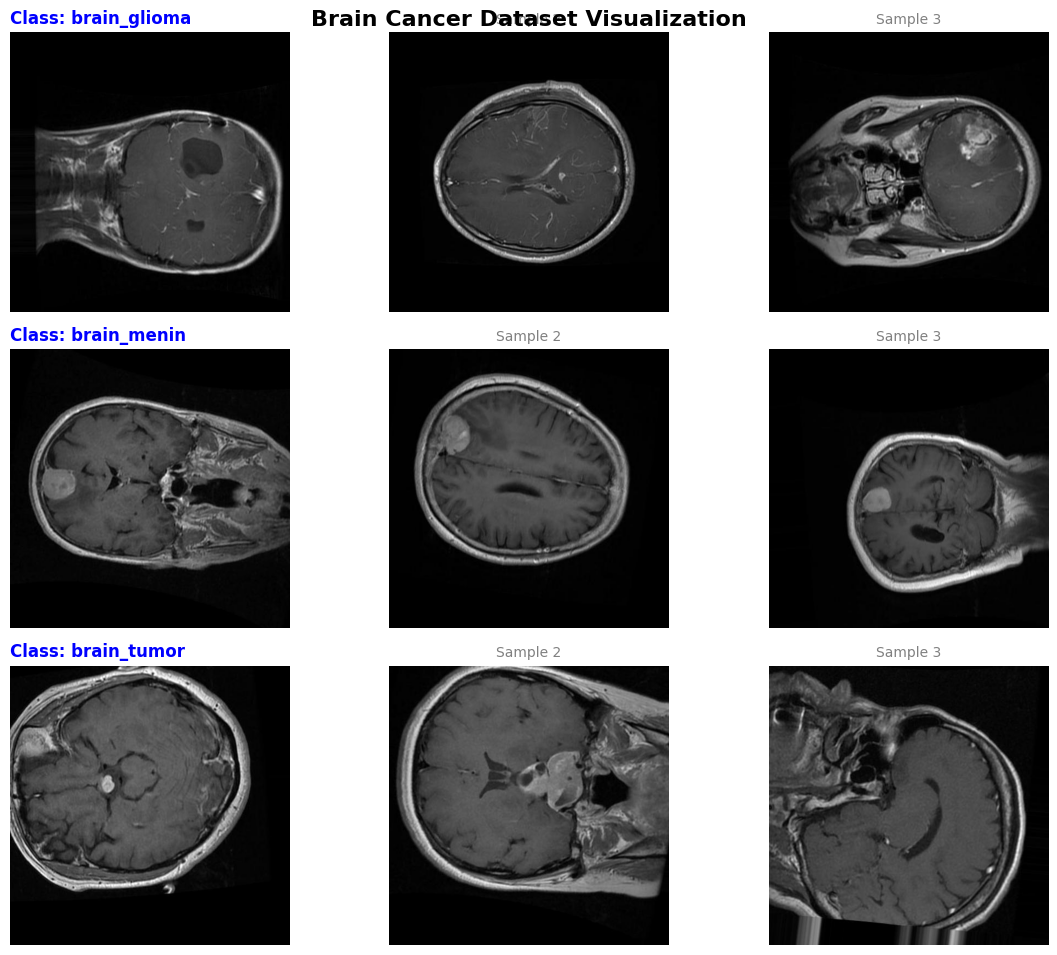

In [8]:
#show data sets
import random
import matplotlib.pyplot as plt
full_dataset = datasets.ImageFolder(root=base_path)

images_per_class = 3
classes = ['brain_glioma', 'brain_menin', 'brain_tumor']

fig, axes = plt.subplots(len(classes), images_per_class, figsize=(12, 10))
fig.suptitle('Brain Cancer Dataset Visualization', fontsize=16, fontweight='bold', y=0.95)

samples = full_dataset.samples
class_to_idx = full_dataset.class_to_idx

for class_idx, class_name in enumerate(classes):
    target_idx = class_to_idx[class_name]
    class_samples = [path for path, idx in samples if idx == target_idx]
    selected_images = random.sample(class_samples, images_per_class)

    for img_idx, img_path in enumerate(selected_images):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax = axes[class_idx, img_idx]
        ax.imshow(img)
        ax.axis('off')

        if img_idx == 0:
            ax.set_title(f"Class: {class_name}", fontsize=12, loc='left', color='blue', fontweight='bold')
        else:
            ax.set_title(f"Sample {img_idx+1}", fontsize=10, color='gray')

plt.tight_layout()
plt.show()

In [9]:
# data transformtion
#data transfroms and loaders
train_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

#data splitting
full_dataset = datasets.ImageFolder(root=base_path)
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset_full, test_dataset_full = torch.utils.data.random_split(full_dataset, [train_size, test_size])


In [10]:
# subset
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)


#

In [11]:
#pytorch data loader apply
train_dataset = TransformedSubset(train_dataset_full, transform=train_transforms)
test_dataset = TransformedSubset(test_dataset_full, transform=test_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))


Train size: 4844
Test size: 1212


In [12]:
#custom data set create
class EnhancedCNN(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.4):
        super().__init__()
        self.features = nn.Sequential(
            # layer1
            nn.Conv2d(3, 64, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),

            # layer2
            nn.Conv2d(64, 128, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),

            # layer3
            nn.Conv2d(128, 256, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(2),

            # layer4
            nn.Conv2d(256, 512, kernel_size=3, padding='same'),
            nn.ReLU(),
            nn.BatchNorm2d(512),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## Hyperparameter Tuning with Optuna (Custom CNN)

We use Optuna to search over the learning rate, weight decay, dropout rate, batch size, and optimizer type for the `EnhancedCNN` model. Each trial trains a fresh model for a few epochs on a validation split and reports the best validation loss achieved; Optuna also prunes clearly unpromising trials early to save time.

In [13]:
def objective(trial):
    # --- search space ---
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.2, 0.6)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    optimizer_name = trial.suggest_categorical("optimizer_name", ["Adam", "AdamW", "RMSprop"])

    # data loaders sized to this trial's batch size
    trial_train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    trial_val_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    model = EnhancedCNN(num_classes=num_classes, dropout_rate=dropout_rate).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "AdamW":
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        optimizer = optim.RMSprop(model.parameters(), lr=lr, weight_decay=weight_decay)

    n_epochs = 5  # short training budget per trial to keep the search fast
    best_trial_val_loss = float("inf")

    for epoch in range(n_epochs):
        model.train()
        for batch_features, batch_labels in trial_train_loader:
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)

            optimizer.zero_grad()
            outputs = model(batch_features)
            loss = criterion(outputs, batch_labels)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_features, batch_labels in trial_val_loader:
                batch_features = batch_features.to(device)
                batch_labels = batch_labels.to(device)
                outputs = model(batch_features)
                loss = criterion(outputs, batch_labels)
                val_loss += loss.item()
        val_loss /= len(trial_val_loader)
        best_trial_val_loss = min(best_trial_val_loss, val_loss)

        # report intermediate value for pruning
        trial.report(val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_trial_val_loss


In [14]:
study = optuna.create_study(direction="minimize", pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=20)

pruned_trials = study.get_trials(deepcopy=False, states=[TrialState.PRUNED])
complete_trials = study.get_trials(deepcopy=False, states=[TrialState.COMPLETE])

print("Study statistics:")
print("  Number of finished trials:", len(study.trials))
print("  Number of pruned trials:", len(pruned_trials))
print("  Number of complete trials:", len(complete_trials))

best_trial = study.best_trial
print("\nBest trial:")
print(f"  Validation loss: {best_trial.value:.4f}")
print("  Params:")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")


[I 2026-07-20 23:07:14,015] A new study created in memory with name: no-name-f8fc9e6c-2395-4c3a-9634-2412d7630579
[I 2026-07-20 23:09:29,670] Trial 0 finished with value: 0.5282215554463235 and parameters: {'lr': 0.0007278504832863147, 'weight_decay': 0.006034439615760134, 'dropout_rate': 0.5087748007329325, 'batch_size': 64, 'optimizer_name': 'Adam'}. Best is trial 0 with value: 0.5282215554463235.
[I 2026-07-20 23:11:29,842] Trial 1 finished with value: 0.41267591244296026 and parameters: {'lr': 0.00018785970308960942, 'weight_decay': 0.005991075411230306, 'dropout_rate': 0.32469463450396163, 'batch_size': 32, 'optimizer_name': 'AdamW'}. Best is trial 1 with value: 0.41267591244296026.
[I 2026-07-20 23:13:28,573] Trial 2 finished with value: 0.6728971882870323 and parameters: {'lr': 0.0010736402431686446, 'weight_decay': 5.516024770595918e-05, 'dropout_rate': 0.32080496956995275, 'batch_size': 32, 'optimizer_name': 'Adam'}. Best is trial 1 with value: 0.41267591244296026.
[I 2026-07-

Study statistics:
  Number of finished trials: 20
  Number of pruned trials: 9
  Number of complete trials: 11

Best trial:
  Validation loss: 0.4065
  Params:
    lr: 5.693076161750169e-05
    weight_decay: 0.0020147418887206704
    dropout_rate: 0.30986037418034595
    batch_size: 32
    optimizer_name: AdamW


In [15]:
# visualize the optimization results
import optuna.visualization as vis

vis.plot_optimization_history(study).show()
vis.plot_param_importances(study).show()


In [16]:
# model declaration and parameters using the best hyperparameters found by Optuna
best_params = study.best_trial.params

model = EnhancedCNN(num_classes=num_classes, dropout_rate=best_params["dropout_rate"]).to(device)
learning_rate = best_params["lr"]
epochs = 50
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

if best_params["optimizer_name"] == "Adam":
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=best_params["weight_decay"])
elif best_params["optimizer_name"] == "AdamW":
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=best_params["weight_decay"])
else:
    optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=best_params["weight_decay"])

# rebuild the data loaders using the best batch size found by Optuna
batch_size = best_params["batch_size"]
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)


In [17]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=1, factor=0.5)

best_val_loss = float('inf')
patience = 4
counter = 0

train_losses = []
val_losses = []


# --- training loop ---
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_features, batch_labels in train_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)

        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    train_losses.append(train_loss)
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for batch_features, batch_labels in test_loader:
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)

            outputs = model(batch_features)
            loss = criterion(outputs, batch_labels)

            val_loss += loss.item()

    val_loss = val_loss / len(test_loader)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_enhanced_cnn_model.pth")
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered! ")
        break

Epoch 1, Train Loss: 0.7394, Val Loss: 0.5962
Epoch 2, Train Loss: 0.5664, Val Loss: 0.4604
Epoch 3, Train Loss: 0.5135, Val Loss: 0.4641
Epoch 4, Train Loss: 0.4836, Val Loss: 0.4374
Epoch 5, Train Loss: 0.4571, Val Loss: 0.4371
Epoch 6, Train Loss: 0.4393, Val Loss: 0.3941
Epoch 7, Train Loss: 0.4190, Val Loss: 0.4159
Epoch 8, Train Loss: 0.4227, Val Loss: 0.3906
Epoch 9, Train Loss: 0.4016, Val Loss: 0.3681
Epoch 10, Train Loss: 0.3942, Val Loss: 0.3614
Epoch 11, Train Loss: 0.3800, Val Loss: 0.3589
Epoch 12, Train Loss: 0.3722, Val Loss: 0.4047
Epoch 13, Train Loss: 0.3702, Val Loss: 0.3602
Epoch 14, Train Loss: 0.3529, Val Loss: 0.3397
Epoch 15, Train Loss: 0.3438, Val Loss: 0.3352
Epoch 16, Train Loss: 0.3410, Val Loss: 0.3432
Epoch 17, Train Loss: 0.3409, Val Loss: 0.3352
Epoch 18, Train Loss: 0.3320, Val Loss: 0.3255
Epoch 19, Train Loss: 0.3296, Val Loss: 0.3247
Epoch 20, Train Loss: 0.3310, Val Loss: 0.3238
Epoch 21, Train Loss: 0.3278, Val Loss: 0.3231
Epoch 22, Train Loss: 

In [18]:
#accuracy and confusion matrix
def evaluate(loader):
    model.eval()
    total, correct = 0, 0
    with torch.no_grad():
        for batch_features, batch_labels in loader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            outputs = model(batch_features)
            _, predicted = torch.max(outputs, 1)
            total += batch_labels.size(0)
            correct += (predicted == batch_labels).sum().item()
    return correct / total

test_acc = evaluate(test_loader)
print(f"Final Test Accuracy: {test_acc * 100:.2f}%")
train_acc = evaluate(train_loader)
print(f"Final Train Accuracy: {train_acc * 100:.2f}%")


Final Test Accuracy: 99.50%
Final Train Accuracy: 99.96%


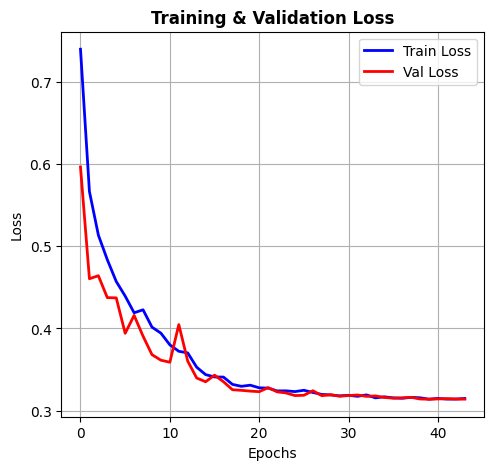

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue', linewidth=2)
plt.plot(val_losses, label='Val Loss', color='red', linewidth=2)
plt.title('Training & Validation Loss', fontsize=12, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

In [20]:
 #cm prediction
all_preds = []
all_labels = []
model.eval()

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        batch_features = batch_features.to(device)
        outputs = model(batch_features)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_labels.numpy())


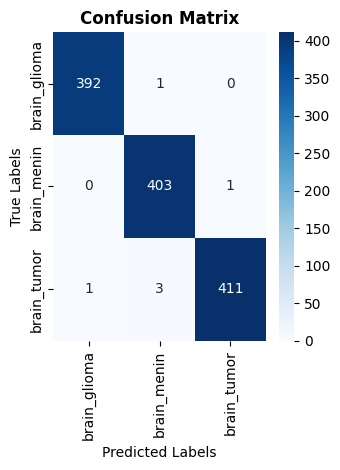

In [21]:
cm = confusion_matrix(all_labels, all_preds)


plt.subplot(1, 2, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=categories, yticklabels=categories)
plt.title('Confusion Matrix', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

plt.tight_layout()
plt.show()

In [22]:
 #calssification report
from sklearn.metrics import classification_report
print(classification_report(all_labels, all_preds, target_names=categories))


              precision    recall  f1-score   support

brain_glioma       1.00      1.00      1.00       393
 brain_menin       0.99      1.00      0.99       404
 brain_tumor       1.00      0.99      0.99       415

    accuracy                           1.00      1212
   macro avg       1.00      1.00      1.00      1212
weighted avg       1.00      1.00      1.00      1212




--- Statistical Analysis (P-Value Calculation) ---
Total Test Samples: 1212
Correct Predictions (True Positives): 1206
Incorrect Predictions (Errors): 6

[Chi-Square Test vs Random Guess Baseline]
Chi-Square Statistic: 2388.1337
Calculated P-Value: 0.0
Result: Statistically SIGNIFICANT (P < 0.05). The model's feature learning is highly reliable.

Visualizing predictions on random test samples...


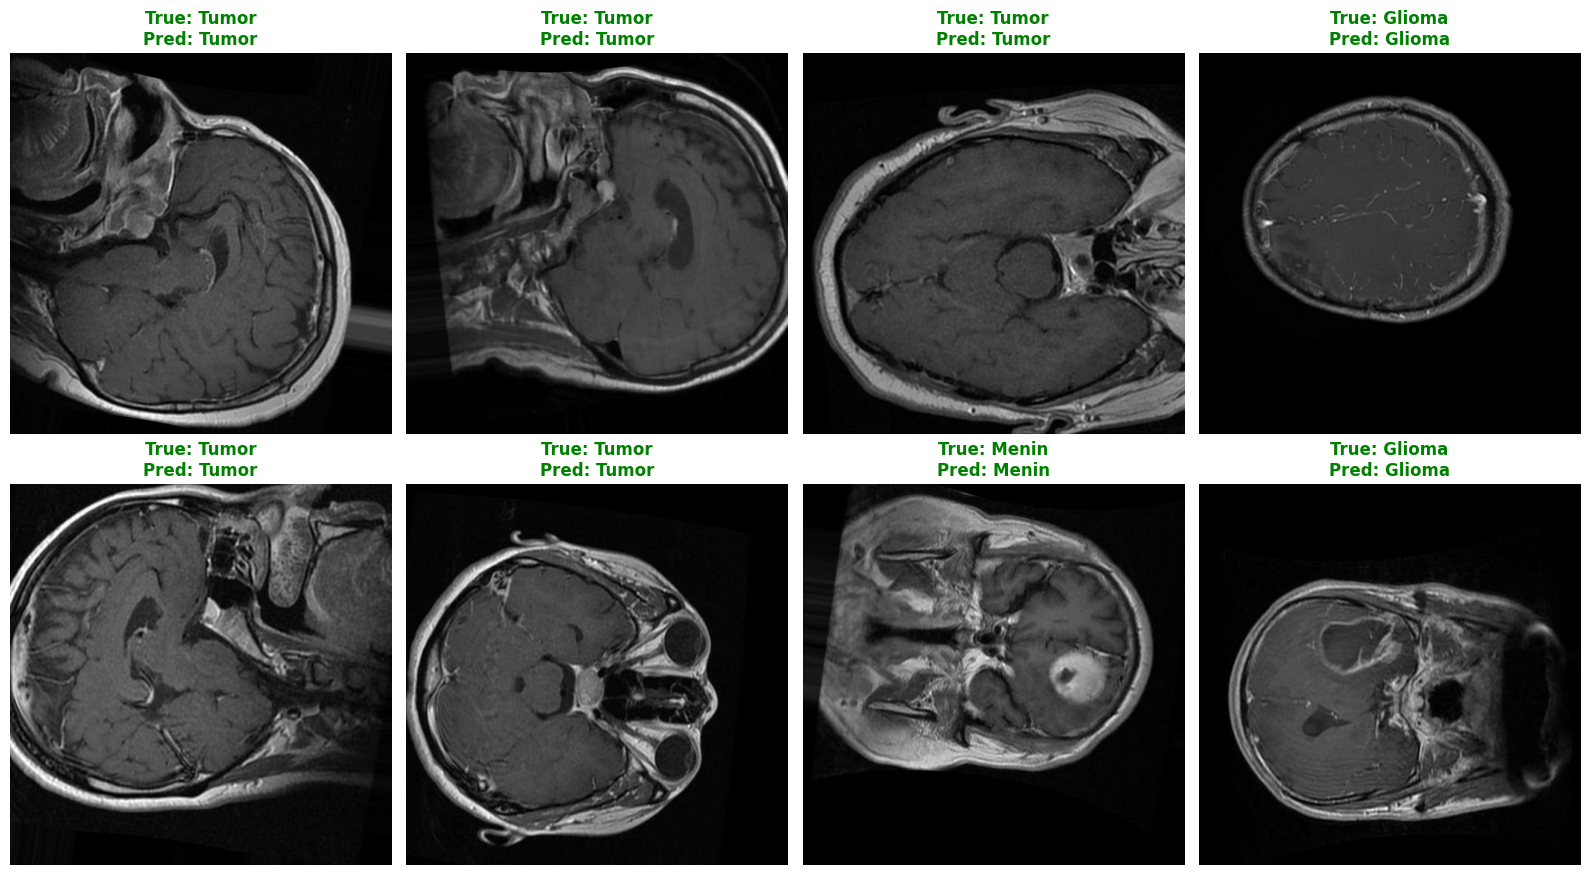

In [23]:
from scipy.stats import chisquare
print("\n--- Statistical Analysis (P-Value Calculation) ---")
true_labels_arr = np.array(all_labels)
pred_labels_arr = np.array(all_preds)

total_samples = len(true_labels_arr)
total_correct = np.sum(true_labels_arr == pred_labels_arr)
total_incorrect = total_samples - total_correct

print(f"Total Test Samples: {total_samples}")
print(f"Correct Predictions (True Positives): {total_correct}")
print(f"Incorrect Predictions (Errors): {total_incorrect}")

# Testing against a random baseline classifier (33.33% chance for 3 classes)
expected_correct = total_samples / 3.0
expected_incorrect = total_samples * (2.0 / 3.0)

chi2_stat, p_value_chi2 = chisquare(f_obs=[total_correct, total_incorrect], f_exp=[expected_correct, expected_incorrect])

print(f"\n[Chi-Square Test vs Random Guess Baseline]")
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"Calculated P-Value: {p_value_chi2}")

if p_value_chi2 < 0.05:
    print("Result: Statistically SIGNIFICANT (P < 0.05). The model's feature learning is highly reliable.")
else:
    print("Result: NOT Statistically Significant. The performance could be due to random chance.")
#visualizing random sample
print("\nVisualizing predictions on random test samples...")
random_indices = random.sample(range(len(test_dataset_full)), 8)
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
axes = axes.ravel()

for i, idx in enumerate(random_indices):
    raw_img, true_label_idx = test_dataset_full[idx]
    transformed_img, _ = test_dataset[idx]

    with torch.no_grad():
        outputs = model(transformed_img.unsqueeze(0).to(device))
        _, pred_label_idx = torch.max(outputs, 1)

    true_name = categories[true_label_idx].split('_')[1].capitalize()
    pred_name = categories[pred_label_idx.item()].split('_')[1].capitalize()
    color = 'green' if true_label_idx == pred_label_idx.item() else 'red'

    axes[i].imshow(raw_img)
    axes[i].axis('off')
    axes[i].set_title(f"True: {true_name}\nPred: {pred_name}", color=color, fontweight='bold')

plt.tight_layout()
plt.show()